# Gaussian Mixture Models

Sometimes our data contains several overlapping populations.

For example, a galaxy colour distribution may contain a blue population and a red population. We observe all the galaxies together, but we do not know which population generated each individual point.

A Gaussian mixture model assumes that the full distribution is a weighted sum of $K$ Gaussian distributions:

$$
p(x_i|\boldsymbol{\theta})
=
\sum_{k=1}^{K}
\pi_k
\mathcal{N}(x_i|\mu_k,\sigma_k)
$$

where:

1. $\mu_k$ is the mean of component $k$
2. $\sigma_k$ is its standard deviation
3. $\pi_k$ is the fraction of the population belonging to component $k$

The weights must satisfy:

$$
\sum_{k=1}^{K}\pi_k=1
$$

astroML uses $\alpha_j$ instead of $\pi_k$, but they represent the same mixture weights.

The difficult part is that we do not know which Gaussian generated each point.

## Hidden Labels, Bayes' Rule and $\gamma_{ik}$

Let $z_i$ be the hidden class label of point $x_i$.

If $z_i=k$, then point $x_i$ was generated by Gaussian component $k$.

We do not observe $z_i$, so we use Bayes' rule to calculate the probability that component $k$ generated point $x_i$:

$$
\gamma_{ik}
=
p(z_i=k|x_i,\boldsymbol{\theta})
$$

$$
\gamma_{ik}
=
\frac{
p(x_i|z_i=k,\boldsymbol{\theta})
p(z_i=k|\boldsymbol{\theta})
}{
\sum_{j=1}^{K}
p(x_i|z_i=j,\boldsymbol{\theta})
p(z_i=j|\boldsymbol{\theta})
}
$$

For a Gaussian mixture:

$$
\gamma_{ik}
=
\frac{
\pi_k
\mathcal{N}(x_i|\mu_k,\sigma_k)
}{
\sum_{j=1}^{K}
\pi_j
\mathcal{N}(x_i|\mu_j,\sigma_j)
}
$$

$\gamma_{ik}$ is called the responsibility.

It tells us how much component $k$ is responsible for point $i$.

For example:

$$
\gamma_{i1}=0.8,
\qquad
\gamma_{i2}=0.2
$$

means that the model gives point $i$ an $80\%$ probability of coming from component 1 and a $20\%$ probability of coming from component 2.

For every point:

$$
\sum_{k=1}^{K}\gamma_{ik}=1
$$

astroML calls the same quantity:

$$
w_{ij}=p(j|x_i)
$$

Therefore, $\gamma_{ik}$ in the videos is the same as $w_{ij}$ in astroML.

## Expectation Maximisation

If the hidden labels were known, we could separate the points into groups and fit one Gaussian to each group.

Expectation maximisation replaces the unknown labels with their expected values, $\gamma_{ik}$.

Start by initialising:

$$
\mu_k,\qquad \sigma_k,\qquad \pi_k
$$

Then repeat the following two steps.

### E-step

Use the current parameter estimates, $\boldsymbol{\theta}^{\mathrm{old}}$, to calculate every responsibility:

$$
\gamma_{ik}
=
p(z_i=k|x_i,\boldsymbol{\theta}^{\mathrm{old}})
$$

These responsibilities are then used to form the expected complete-data log-likelihood:

$$
Q(\boldsymbol{\theta}|\boldsymbol{\theta}^{\mathrm{old}})
=
\mathbb{E}_{z|x,\boldsymbol{\theta}^{\mathrm{old}}}
\left[
\ln p(x,z|\boldsymbol{\theta})
\right]
$$

For a Gaussian mixture:

$$
Q(\boldsymbol{\theta}|\boldsymbol{\theta}^{\mathrm{old}})
=
\sum_{i=1}^{N}
\sum_{k=1}^{K}
\gamma_{ik}
\left[
\ln \pi_k
+
\ln \mathcal{N}(x_i|\mu_k,\sigma_k)
\right]
$$

The expectation is calculated using the **old/current parameters**, while $Q$ is treated as a function of the possible new parameters.

### M-step

Choose the new parameters which maximise the expected log-likelihood:

$$
\boldsymbol{\theta}^{\mathrm{new}}
=
\underset{\boldsymbol{\theta}}{\operatorname{argmax}}
\;
Q(\boldsymbol{\theta}|\boldsymbol{\theta}^{\mathrm{old}})
$$

For a one-dimensional Gaussian mixture, this gives:

$$
N_k=\sum_{i=1}^{N}\gamma_{ik}
$$

$$
\mu_k^{\mathrm{new}}
=
\frac{
\sum_i\gamma_{ik}x_i
}{
N_k
}
$$

$$
(\sigma_k^2)^{\mathrm{new}}
=
\frac{
\sum_i
\gamma_{ik}
(x_i-\mu_k^{\mathrm{new}})^2
}{
N_k
}
$$

$$
\pi_k^{\mathrm{new}}
=
\frac{N_k}{N}
$$

So the whole process is simply:

$$
\text{Initialise }
\mu_k,\sigma_k,\pi_k
$$

$$
\downarrow
$$

$$
\text{E-step: calculate }\gamma_{ik}\text{ and }Q
$$

$$
\downarrow
$$

$$
\text{M-step: update }\mu_k,\sigma_k,\pi_k
\text{ to maximise }Q
$$

$$
\downarrow
$$

$$
\text{Repeat until the parameters stop changing}
$$

astroML presents the same procedure using $w_{ij}$ instead of $\gamma_{ik}$ and directly gives the weighted update equations.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.mixture import GaussianMixture

random_state = np.random.RandomState(seed=1)

# The three Gaussian populations used in the astroML example
X = np.concatenate([
    random_state.normal(-1, 1.5, 350),
    random_state.normal(0, 1.0, 500),
    random_state.normal(3, 0.5, 150)
]).reshape(-1, 1)

component_numbers = np.arange(1, 11)
models = []

for number in component_numbers:
    model = GaussianMixture(
        n_components=number,
        n_init=10,
        random_state=1
    )
    model.fit(X)
    models.append(model)

AIC = np.array([
    model.aic(X)
    for model in models
])

BIC = np.array([
    model.bic(X)
    for model in models
])

best_model = models[np.argmin(BIC)]

print(
    "Best number of components from AIC:",
    component_numbers[np.argmin(AIC)]
)
print(
    "Best number of components from BIC:",
    best_model.n_components
)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-dhl6jx13 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Best number of components from AIC: 3
Best number of components from BIC: 3


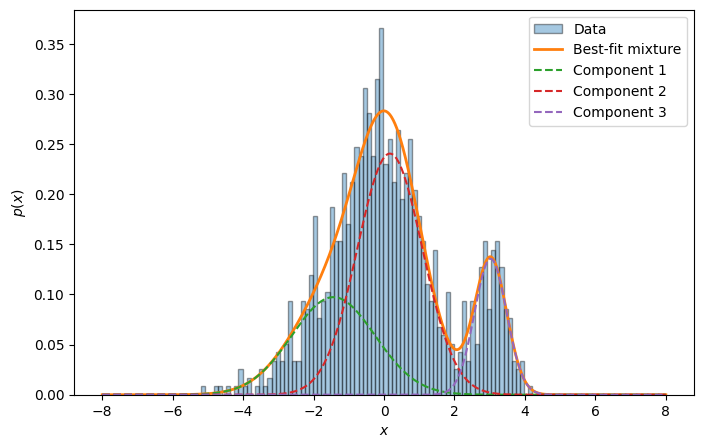

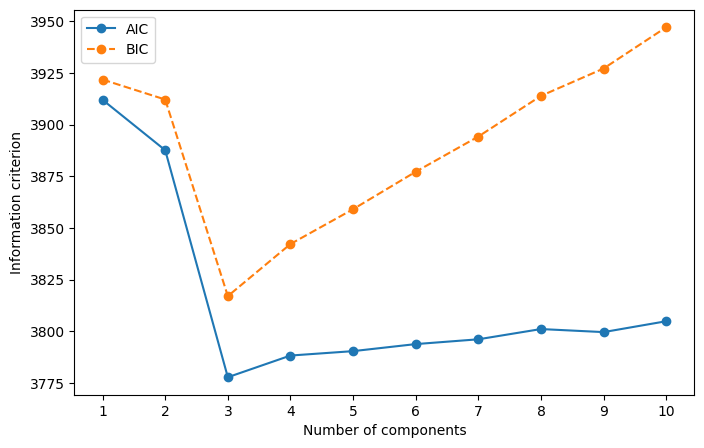

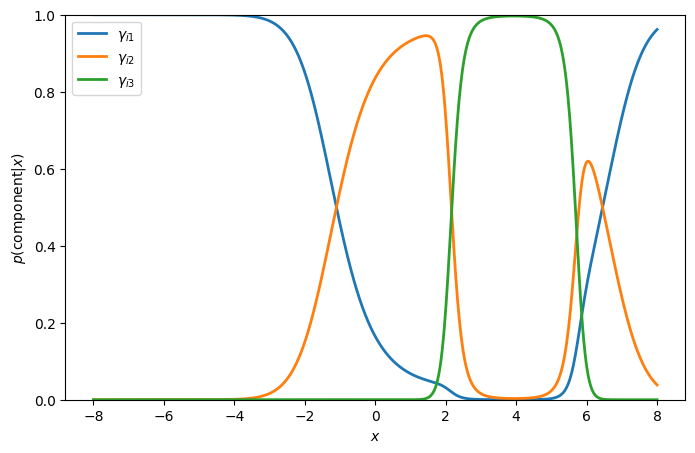

In [2]:
x = np.linspace(-8, 8, 1000).reshape(-1, 1)

log_probability = best_model.score_samples(x)
mixture_pdf = np.exp(log_probability)

# These are gamma_ik values for each x and each component
responsibilities = best_model.predict_proba(x)

individual_pdfs = (
    responsibilities
    * mixture_pdf[:, np.newaxis]
)

# Put the components in order of increasing mean
order = np.argsort(best_model.means_.ravel())

responsibilities = responsibilities[:, order]
individual_pdfs = individual_pdfs[:, order]

plt.figure(figsize=(8, 5))
plt.hist(
    X.ravel(),
    bins=80,
    density=True,
    alpha=0.4,
    edgecolor="black",
    label="Data"
)
plt.plot(
    x.ravel(),
    mixture_pdf,
    linewidth=2,
    label="Best-fit mixture"
)

for k in range(best_model.n_components):
    plt.plot(
        x.ravel(),
        individual_pdfs[:, k],
        linestyle="--",
        label=f"Component {k + 1}"
    )

plt.xlabel("$x$")
plt.ylabel("$p(x)$")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    component_numbers,
    AIC,
    marker="o",
    label="AIC"
)
plt.plot(
    component_numbers,
    BIC,
    marker="o",
    linestyle="--",
    label="BIC"
)
plt.xticks(component_numbers)
plt.xlabel("Number of components")
plt.ylabel("Information criterion")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

for k in range(best_model.n_components):
    plt.plot(
        x.ravel(),
        responsibilities[:, k],
        linewidth=2,
        label=f"$\\gamma_{{i{k + 1}}}$"
    )

plt.xlabel("$x$")
plt.ylabel("$p(\\mathrm{component}|x)$")
plt.ylim(0, 1)
plt.legend()
plt.show()

## What the Results Mean

The first plot shows the complete mixture and the individual Gaussian components.

The final plot shows the responsibilities, $\gamma_{ik}$. Where two components overlap, a point can have a meaningful probability of belonging to both. This is why a Gaussian mixture gives a soft classification rather than forcing every point into one class with complete certainty.

More components normally improve the likelihood, but too many can overfit the data. We therefore compare AIC or BIC and choose the model with the smallest value. In this example, both identify the three components used to generate the data.

Important limitations:

1. EM finds a local maximum, so different initial values can produce different results
2. Outliers, sparse data or repeated points can cause numerical problems
3. One fitted Gaussian component does not automatically prove that one separate physical population exists
4. Standard Gaussian mixtures assume that measurement errors are negligible

For equal Gaussian measurement errors, $e$, astroML gives the approximate intrinsic width:

$$
\sigma_k^*
=
\sqrt{\sigma_k^2-e^2}
$$

For different errors, $e_i$, the measurement error must be included directly in the component width:

$$
\sqrt{\sigma_k^2+e_i^2}
$$

The standard explicit variance update then no longer works.

### Summary

A Gaussian mixture assumes that the data was generated by several hidden Gaussian populations.

Bayes' rule gives:

$$
\gamma_{ik}
=
p(z_i=k|x_i,\boldsymbol{\theta})
$$

The E-step calculates $\gamma_{ik}$ and therefore the expected complete-data log-likelihood, $Q$.

The M-step updates $\mu_k$, $\sigma_k$ and $\pi_k$ to maximise $Q$.

The two steps are repeated until convergence.

### References

- Ivezić et al., *Statistics, Data Mining, and Machine Learning in Astronomy*, Section 4.4
- [MLE Applied to Gaussian Mixtures — astroML](https://www.astroml.org/astroML-notebooks/chapter4/astroml_chapter4_Gaussian_mixtures.html)
- [Gaussian Mixture Models](https://www.youtube.com/watch?v=wT2yLNUfyoM)
- [Gaussian Mixture Model — Stanford Online](https://www.youtube.com/watch?v=EWd1xRkyEog)